**Chapter 2 – End-to-end Machine Learning project**

*Welcome to Machine Learning Housing Corp.! Your task is to predict median house values in Californian districts, given a number of features from these districts.*

*This notebook contains all the sample code and solutions to the exercices in chapter 2.*

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml2/blob/master/02_end_to_end_machine_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml2/blob/master/02_end_to_end_machine_learning_project.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures. We also check that Python 3.5 or later is installed (although Python 2.x may work, it is deprecated so we strongly recommend you use Python 3 instead), as well as Scikit-Learn ≥0.20.

In [2]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Get the Data

## Download the Data

In [3]:
import os
import tarfile
import urllib.request

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"

def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    if not os.path.isdir(housing_path):
        os.makedirs(housing_path)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    #Modified due to depreciation warning..
    #housing_tgz = tarfile.open(tgz_path)
    #housing_tgz.extractall(path=housing_path)
    # use context manager and safe filter
    with tarfile.open(tgz_path) as housing_tgz:
        # 'data' allows only regular files/directories (safe default for 3.14+)
        housing_tgz.extractall(path=housing_path, filter='data')
    housing_tgz.close()

In [4]:
fetch_housing_data()

In [5]:
#import pandas as pd

#def load_housing_data(housing_path=HOUSING_PATH):
 #   csv_path = os.path.join(housing_path, "housing.csv")
  #  return pd.read_csv(csv_path)


# New code
from pathlib import Path
import pandas as pd 
import tarfile
import urllib.request

def load_housing_data(): 
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file(): 
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball: 
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))




## Take a Quick Look at the Data Structure

In [6]:
housing = load_housing_data()
housing.head(n=7)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY


In [7]:
housing.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
housing["ocean_proximity"].value_counts(normalize=True)

ocean_proximity
<1H OCEAN     0.442636
INLAND        0.317393
NEAR OCEAN    0.128779
NEAR BAY      0.110950
ISLAND        0.000242
Name: proportion, dtype: float64

In [9]:
#But Where to use this data, How to Use if i have a normalized value for each objects such as Inland, Near Ocean, and so on. What gives it to me?
# Is there any risk for overfitting, by exploring each and every details? 
#
# Slide. 
# Book page 53 3rd Edition 

In [10]:
# More general question can be, Why we need different 

In [11]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Saving figure attribute_histogram_plots


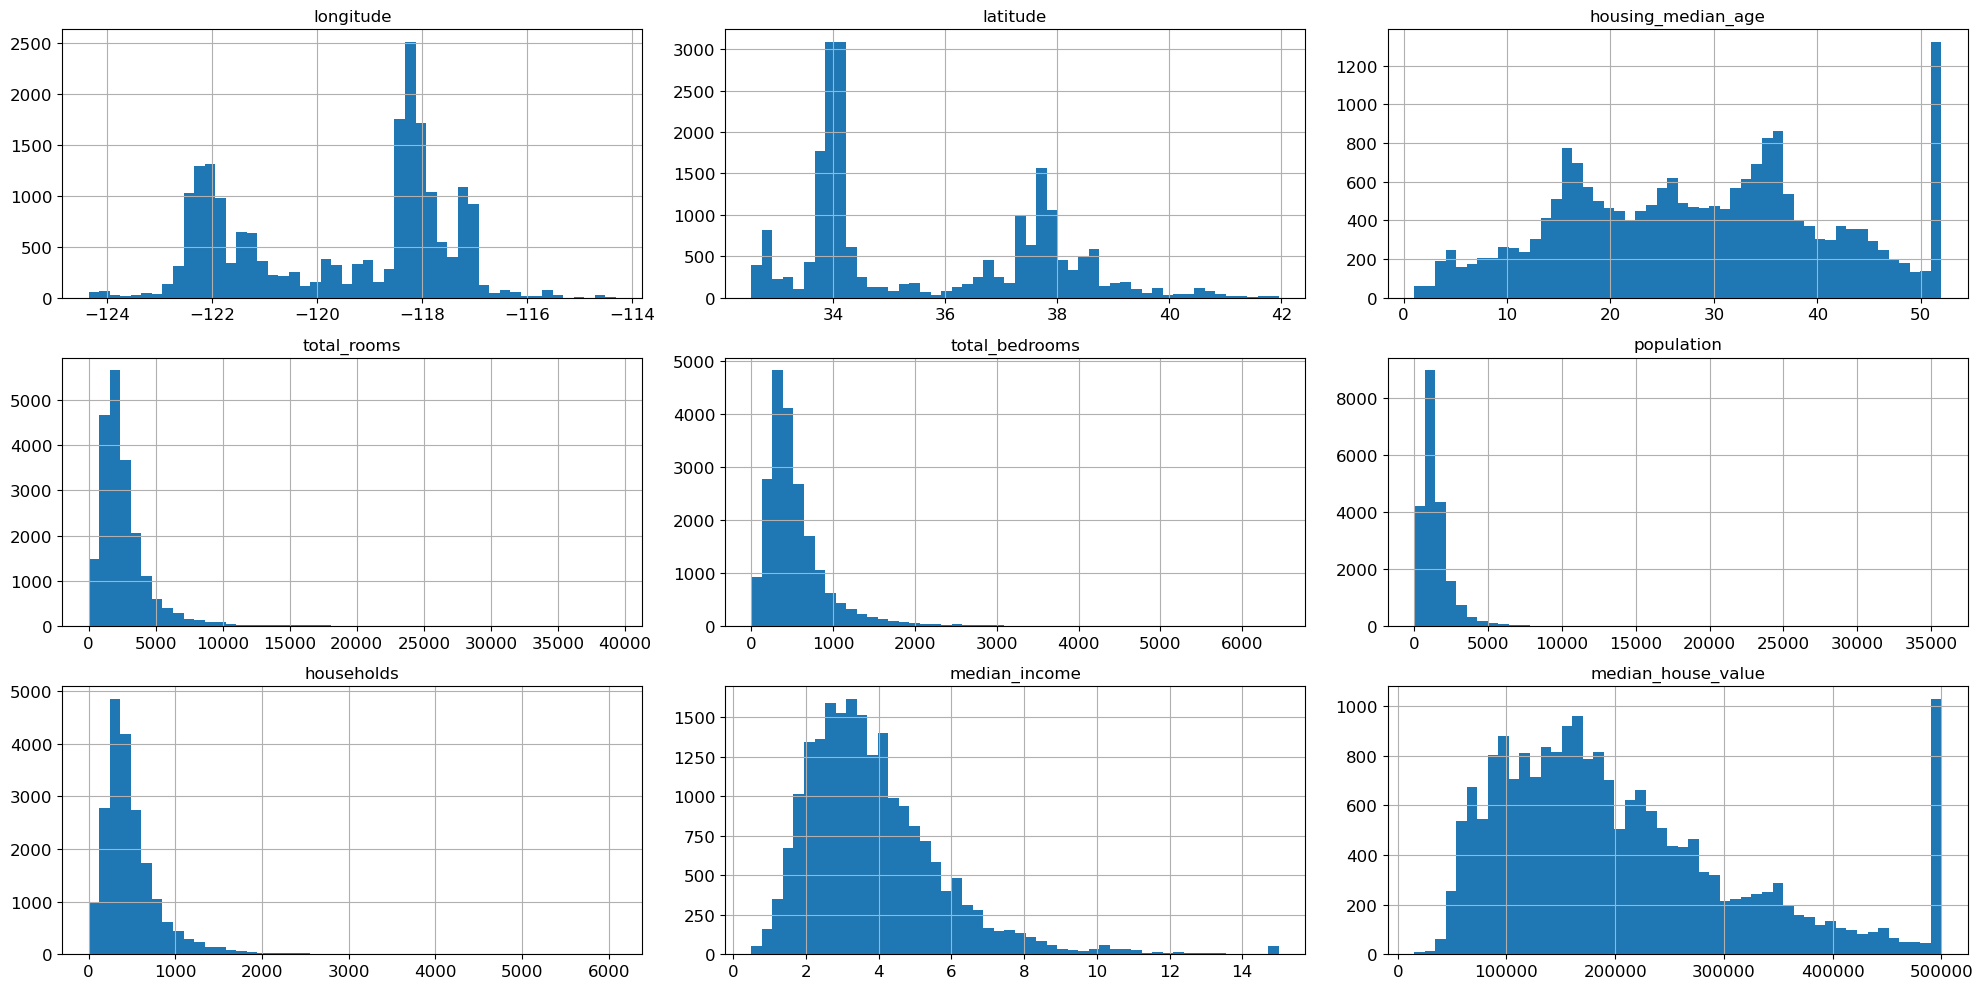

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20, 10))
save_fig("attribute_histogram_plots")
plt.show()

## Create a Test Set

In [13]:
# to make this notebook's output identical at every run
np.random.seed(42)

In [14]:
import numpy as np

# For illustration only. Sklearn has train_test_split()
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [15]:
train_set, test_set = split_train_test(housing, 0.2)
len(train_set)

16512

In [16]:
len(test_set)

4128

In [17]:
#possible implementation to create a consistent test set. 

from zlib import crc32

def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

The implementation of `test_set_check()` above works fine in both Python 2 and Python 3. In earlier releases, the following implementation was proposed, which supported any hash function, but was much slower and did not support Python 2:

In [18]:
import hashlib

def test_set_check(identifier, test_ratio, hash=hashlib.md5):
    return hash(np.int64(identifier)).digest()[-1] < 256 * test_ratio

If you want an implementation that supports any hash function and is compatible with both Python 2 and Python 3, here is one:

In [19]:
def test_set_check(identifier, test_ratio, hash=hashlib.md5):
    return bytearray(hash(np.int64(identifier)).digest())[-1] < 256 * test_ratio

In [20]:
#Creating index column

housing_with_id = housing.reset_index()   # adds an `index` column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [21]:
#The simplest solution is to use the row as index 
# But be careful, make sure the appended data is added to the end og the table
#It is also importnat that no row ever get deleted. 

housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [22]:
test_set.head()

,index,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,id
4,4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,-122212.15
5,5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY,-122212.15
11,11,-122.26,37.85,52.0,3503.0,752.0,1504.0,734.0,3.2705,241800.0,NEAR BAY,-122222.15
20,20,-122.27,37.85,40.0,751.0,184.0,409.0,166.0,1.3578,147500.0,NEAR BAY,-122232.15
23,23,-122.27,37.84,52.0,1688.0,337.0,853.0,325.0,2.1806,99700.0,NEAR BAY,-122232.16


In [23]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [24]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20046,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
3024,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
15663,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
20484,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
9814,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


In [25]:
housing["median_income"].hist()

<Axes: >

In [26]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

In [27]:
housing["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

In [28]:
housing["income_cat"].hist()

<Axes: >

In [29]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
start_splits = []
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.iloc[train_index]
    strat_test_set = housing.iloc[test_index]
    start_splits.append([strat_test_set, strat_test_set])

In [30]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
19712,-121.64,39.15,15.0,2659.0,396.0,1159.0,407.0,5.2340,124900.0,INLAND,4
7414,-118.23,33.95,43.0,1683.0,520.0,2190.0,494.0,2.2391,152800.0,<1H OCEAN,2
3110,-117.70,35.60,16.0,2678.0,483.0,1473.0,487.0,3.8580,70200.0,INLAND,3
20210,-119.23,34.30,18.0,1713.0,244.0,690.0,239.0,6.9483,404300.0,NEAR OCEAN,5
4766,-118.36,34.03,43.0,1690.0,379.0,1017.0,359.0,2.1078,133500.0,<1H OCEAN,2
...,...,...,...,...,...,...,...,...,...,...,...
19039,-121.99,38.36,33.0,146.0,31.0,75.0,31.0,3.5179,84400.0,INLAND,3
10454,-117.66,33.48,22.0,809.0,180.0,334.0,157.0,2.3846,500001.0,<1H OCEAN,2
3353,-121.03,40.35,52.0,5486.0,1044.0,1977.0,754.0,2.1833,49500.0,INLAND,2
2797,-118.18,36.63,23.0,2311.0,487.0,1019.0,384.0,2.2574,104700.0,INLAND,2


In [31]:
strat_train_set, strat_test_set = start_splits[0]

In [32]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN,5
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN,4
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN,3
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN,3
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,110000.0,<1H OCEAN,2
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,118800.0,<1H OCEAN,2
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,293800.0,<1H OCEAN,4
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,335700.0,<1H OCEAN,4


In [33]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [34]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN,5
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN,4
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN,3
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN,3
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,110000.0,<1H OCEAN,2
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,118800.0,<1H OCEAN,2
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,293800.0,<1H OCEAN,4
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,335700.0,<1H OCEAN,4


In [35]:
housing["income_cat"].value_counts() / len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [36]:
#Skilearn have few functions to split datasets into multiplle subset of various ways.
# train_test_split() is one of them.  

def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [37]:
strat_test_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN,5
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN,4
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN,3
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN,3
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,110000.0,<1H OCEAN,2
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,118800.0,<1H OCEAN,2
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,293800.0,<1H OCEAN,4
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,335700.0,<1H OCEAN,4


In [38]:
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [39]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True, errors='ignore')

C:\Users\suraj\AppData\Local\Temp\ipykernel_34408\1052011160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True, errors='ignore')
C:\Users\suraj\AppData\Local\Temp\ipykernel_34408\1052011160.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  set_.drop("income_cat", axis=1, inplace=True, errors='ignore')


# Discover and Visualize the Data to Gain Insights

In [40]:
housing = strat_train_set.copy()

In [41]:
strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,500001.0,<1H OCEAN
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,162500.0,<1H OCEAN
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,204600.0,<1H OCEAN
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,159700.0,<1H OCEAN
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,184000.0,NEAR OCEAN
...,...,...,...,...,...,...,...,...,...,...
12182,-117.29,33.72,19.0,2248.0,427.0,1207.0,368.0,2.8170,110000.0,<1H OCEAN
7275,-118.24,33.99,33.0,885.0,294.0,1270.0,282.0,2.1615,118800.0,<1H OCEAN
17223,-119.72,34.44,43.0,1781.0,342.0,663.0,358.0,4.7000,293800.0,<1H OCEAN
10786,-117.91,33.63,30.0,2071.0,412.0,1081.0,412.0,4.9125,335700.0,<1H OCEAN


## Visualizing Geographical Data

In [42]:
housing.plot(kind="scatter", x="longitude", y="latitude")
save_fig("bad_visualization_plot")

Saving figure bad_visualization_plot


In [43]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)
save_fig("better_visualization_plot")

Saving figure better_visualization_plot


The argument `sharex=False` fixes a display bug (the x-axis values and legend were not displayed). This is a temporary fix (see: https://github.com/pandas-dev/pandas/issues/10611 ). Thanks to Wilmer Arellano for pointing it out.

In [44]:
housing.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=housing["population"]/100, label="population", figsize=(10,7),
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             sharex=False)
plt.legend()
save_fig("housing_prices_scatterplot")

Saving figure housing_prices_scatterplot


In [45]:
# Download the California image
images_path = os.path.join(PROJECT_ROOT_DIR, "images", "end_to_end_project")
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "california.png"
print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))

('.\\images\\end_to_end_project\\california.png',
 <http.client.HTTPMessage at 0x2161710c640>)

Saving figure california_housing_prices_plot


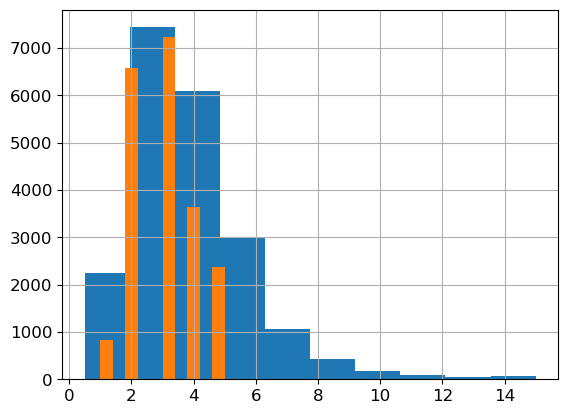

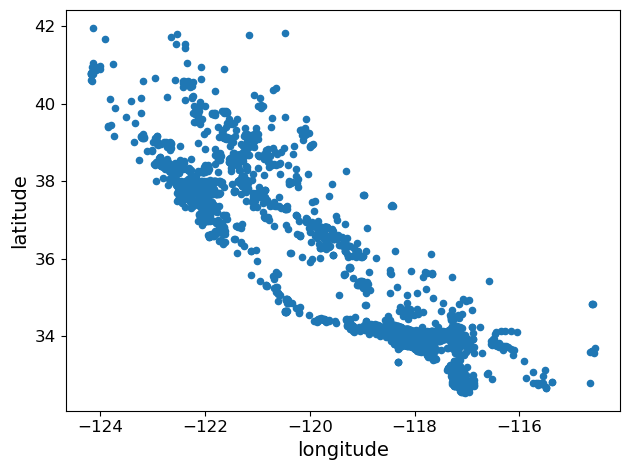

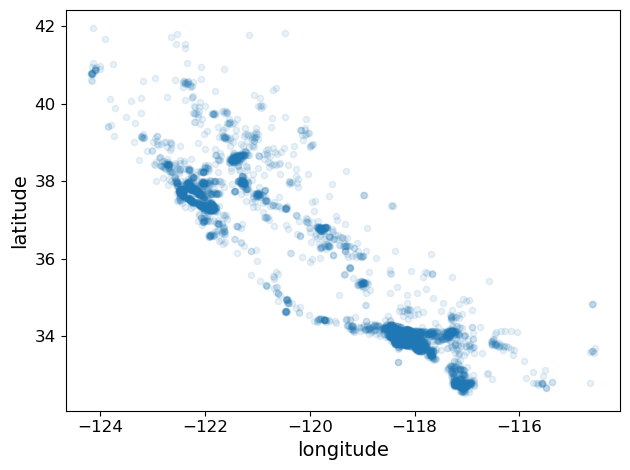

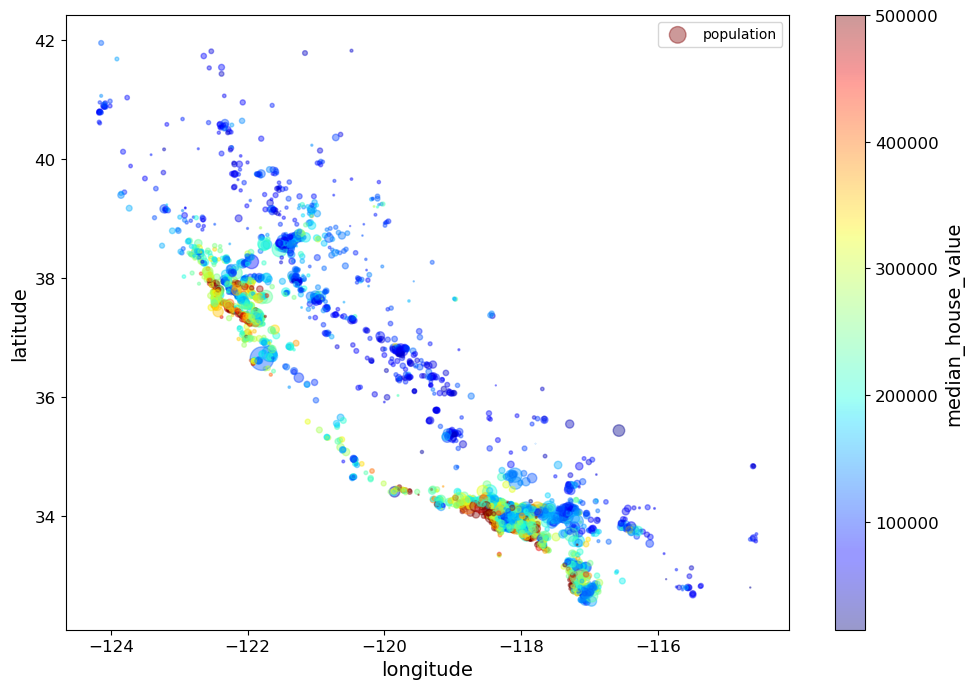

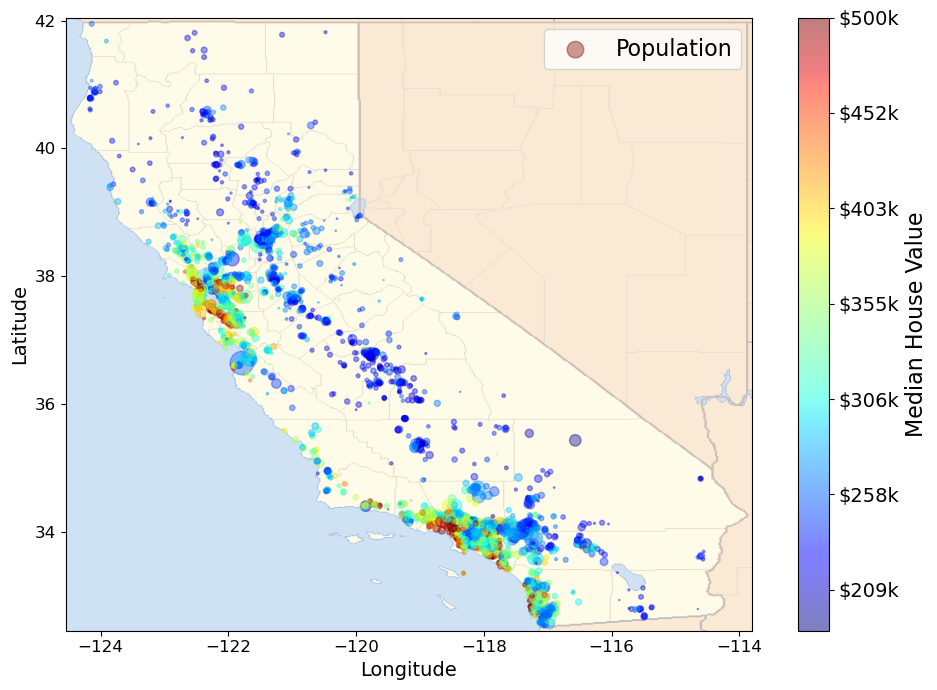

In [46]:
import matplotlib.image as mpimg
california_img=mpimg.imread(os.path.join(images_path, filename))
ax = housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                  s=housing['population']/100, label="Population",
                  c="median_house_value", cmap=plt.get_cmap("jet"),
                  colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
save_fig("california_housing_prices_plot")
plt.show()

## Looking for Correlations

In [47]:
#corr_matrix = housing.corr()
# pearson's r used here... with corr()

corr_matrix = housing.corr(numeric_only=True)

In [48]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.691867
total_rooms           0.131296
housing_median_age    0.071210
households            0.070947
total_bedrooms        0.057247
population           -0.016164
longitude            -0.039848
latitude             -0.150336
Name: median_house_value, dtype: float64

 Another way to check for correlation between attributes is to use Pandas’
 scatter_matrix function, which plots every numerical attribute against every other
 numerical attribute. Since there are now 11 numerical attributes, you would get 112 =
 121 plots, which would not fit on a page, so let’s just focus on a few promising
 attributes that seem most correlated with the median housing value.

In [49]:
# from pandas.tools.plotting import scatter_matrix # For older versions of Pandas
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
save_fig("scatter_matrix_plot")

Saving figure scatter_matrix_plot


In [50]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1)
plt.axis([0, 16, 0, 550000])
save_fig("income_vs_house_value_scatterplot")

Saving figure income_vs_house_value_scatterplot


## Experimenting with Attribute Combinations

 Hopefully the previous sections gave you an idea of a few ways you can explore the
 data and gain insights. You identified a few data quirks that you may want to clean up
 before feeding the data to a Machine Learning algorithm, and you found interesting
 correlations between attributes, in particular with the target attribute. You also
 noticed that some attributes have a tail-heavy distribution, so you may want to trans
form them (e.g., by computing their logarithm). Of course, your mileage will vary
 considerably with each project, but the general ideas are similar.
 One last thing you may want to do before actually preparing the data for Machine
 Learning algorithms is to try out various attribute combinations. For example, the
 total number of rooms in a district is not very useful if you don’t know how many
 households there are. What you really want is the number of rooms per household.
 Similarly, the total number of bedrooms by itself is not very useful: you probably
 want to compare it to the number of rooms. And the population per household also
 seems like an interesting attribute combination to look at. Let’s create these new
 attributes:

In [51]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]
housing["population_per_household"]=housing["population"]/housing["households"]

In [52]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value          1.000000
median_income               0.691867
rooms_per_household         0.192731
total_rooms                 0.131296
housing_median_age          0.071210
households                  0.070947
total_bedrooms              0.057247
population                 -0.016164
longitude                  -0.039848
population_per_household   -0.134999
latitude                   -0.150336
bedrooms_per_room          -0.240481
Name: median_house_value, dtype: float64

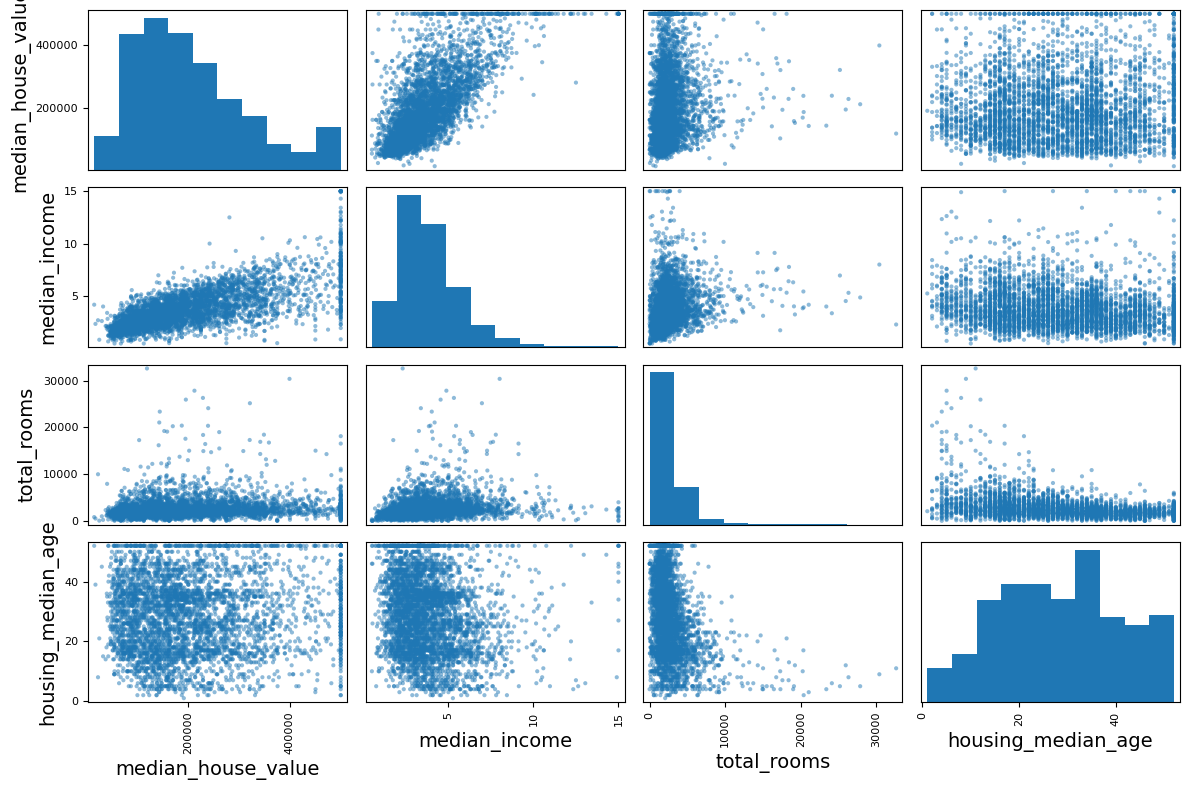

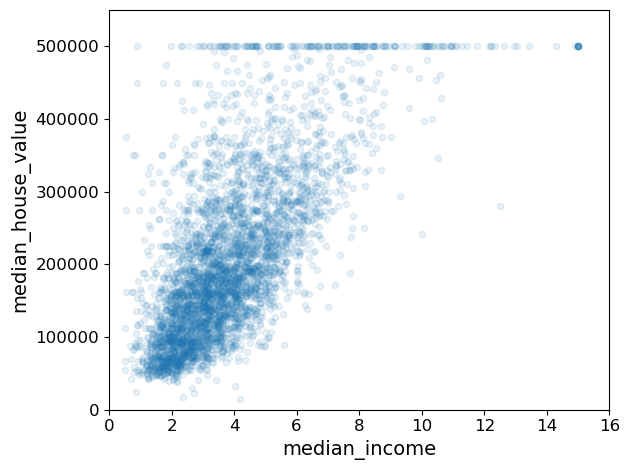

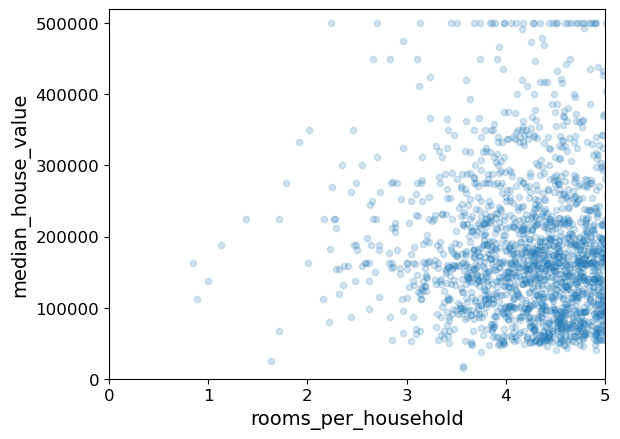

In [53]:
housing.plot(kind="scatter", x="rooms_per_household", y="median_house_value",
             alpha=0.2)
plt.axis([0, 5, 0, 520000])
plt.show()

In [54]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,4128.000000,4128.000000,4128.000000,4128.000000,4079.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4079.000000,4128.000000
mean,-119.545981,35.602049,28.583818,2688.656250,549.721746,1448.634205,509.651163,3.849818,206257.795058,5.383375,0.213705,2.967399
std,2.010400,2.127889,12.629796,2345.997876,454.528621,1197.164964,407.677609,1.879332,114176.653346,1.822694,0.060349,1.584661
min,-124.180000,32.550000,1.000000,2.000000,1.000000,5.000000,1.000000,0.499900,14999.000000,0.846154,0.100000,1.089286
25%,-121.780000,33.920000,18.000000,1474.000000,301.000000,805.750000,283.000000,2.542675,118900.000000,4.434273,0.175927,2.424681
50%,-118.460000,34.220000,28.000000,2159.500000,442.000000,1172.500000,416.000000,3.513200,181300.000000,5.218307,0.203604,2.822308
75%,-117.980000,37.690000,37.000000,3171.250000,653.000000,1754.250000,613.250000,4.739225,268850.000000,6.031716,0.239791,3.286534
max,-114.560000,41.950000,52.000000,32627.000000,6445.000000,28566.000000,6082.000000,15.000100,500001.000000,37.063492,1.000000,63.750000


# Prepare the Data for Machine Learning Algorithms

In [55]:
housing = strat_train_set.drop("median_house_value", axis=1) # drop labels for training set
housing_labels = strat_train_set["median_house_value"].copy()

## Data Cleaning

In the book 3 options are listed:

```python
housing.dropna(subset=["total_bedrooms"])    # option 1
housing.drop("total_bedrooms", axis=1)       # option 2
median = housing["total_bedrooms"].median()  # option 3
housing["total_bedrooms"].fillna(median, inplace=True)
```

To demonstrate each of them, let's create a copy of the housing dataset, but keeping only the rows that contain at least one null. Then it will be easier to visualize exactly what each option does:

In [56]:
sample_incomplete_rows = housing[housing.isnull().any(axis=1)].head()
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
11441,-117.98,33.73,18.0,3833.0,NaN,2192.0,996.0,3.4679,<1H OCEAN
19890,-119.15,36.29,18.0,1435.0,NaN,657.0,254.0,2.4281,INLAND
3912,-118.55,34.19,18.0,5862.0,NaN,3161.0,1280.0,3.1106,<1H OCEAN
8530,-118.35,33.90,31.0,1547.0,NaN,956.0,287.0,3.4698,<1H OCEAN
11311,-117.96,33.78,33.0,1520.0,NaN,658.0,242.0,4.8750,<1H OCEAN


In [57]:
sample_incomplete_rows.dropna(subset=["total_bedrooms"])    # option 1

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity


In [58]:
sample_incomplete_rows.drop("total_bedrooms", axis=1)       # option 2

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,ocean_proximity
11441,-117.98,33.73,18.0,3833.0,2192.0,996.0,3.4679,<1H OCEAN
19890,-119.15,36.29,18.0,1435.0,657.0,254.0,2.4281,INLAND
3912,-118.55,34.19,18.0,5862.0,3161.0,1280.0,3.1106,<1H OCEAN
8530,-118.35,33.90,31.0,1547.0,956.0,287.0,3.4698,<1H OCEAN
11311,-117.96,33.78,33.0,1520.0,658.0,242.0,4.8750,<1H OCEAN


In [59]:
median = housing["total_bedrooms"].median()
sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True) # option 3

median

C:\Users\suraj\AppData\Local\Temp\ipykernel_34408\3029507002.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sample_incomplete_rows["total_bedrooms"].fillna(median, inplace=True) # option 3


442.0

In [60]:
sample_incomplete_rows

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
11441,-117.98,33.73,18.0,3833.0,442.0,2192.0,996.0,3.4679,<1H OCEAN
19890,-119.15,36.29,18.0,1435.0,442.0,657.0,254.0,2.4281,INLAND
3912,-118.55,34.19,18.0,5862.0,442.0,3161.0,1280.0,3.1106,<1H OCEAN
8530,-118.35,33.90,31.0,1547.0,442.0,956.0,287.0,3.4698,<1H OCEAN
11311,-117.96,33.78,33.0,1520.0,442.0,658.0,242.0,4.8750,<1H OCEAN


 If you choose option 3, you should compute the median value on the training set, and
 use it to fill the missing values in the training set, but also don’t forget to save the
 median value that you have computed. You will need it later to replace missing values
 in the test set when you want to evaluate your system, and also once the system goes
 live to replace missing values in new data.
 Scikit-Learn provides a handy class to take care of missing values: SimpleImputer.
 Here is how to use it. First, you need to create a SimpleImputer instance, specifying
 that you want to replace each attribute’s missing values with the median of that
 attribute:

In [61]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

Remove the text attribute because median can only be calculated on numerical attributes:

In [62]:
housing_num = housing.drop("ocean_proximity", axis=1)
# alternatively: housing_num = housing.select_dtypes(include=[np.number])

Now you can fit the imputer instance to the training data using the fit() method:

In [63]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [64]:
imputer.statistics_

array([-118.46  ,   34.22  ,   28.    , 2159.5   ,  442.    , 1172.5   ,
        416.    ,    3.5132])

Check that this is the same as manually computing the median of each attribute:

In [65]:
# Select only numeric columns
housing_num_numeric = housing_num.select_dtypes(include=[np.number])

# Now compute median safely
medians = housing_num_numeric.median()

print(medians)

#housing_num.median()
median_array = medians.values

longitude             -118.4600
latitude                34.2200
housing_median_age      28.0000
total_rooms           2159.5000
total_bedrooms         442.0000
population            1172.5000
households             416.0000
median_income            3.5132
dtype: float64


Transform the training set:

Scikit-Learn’s API is remarkably well designed. The main design principles are:17
 •Consistency. All objects share a consistent and simple interface:
 —Estimators. Any object that can estimate some parameters based on a dataset
 is called an estimator (e.g., an imputer is an estimator). The estimation itself is
 performed by the fit() method, and it takes only a dataset as a parameter (or
 two for supervised learning algorithms; the second dataset contains the
 labels). Any other parameter needed to guide the estimation process is con
sidered a hyperparameter (such as an imputer’s strategy), and it must be set
 as an instance variable (generally via a constructor parameter).
 —Transformers. Some estimators (such as an imputer) can also transform a
 dataset; these are called transformers. Once again, the API is quite simple: the
 transformation is performed by the transform() method with the dataset to
 transform as a parameter. It returns the transformed dataset. This transforma
tion generally relies on the learned parameters, as is the case for an imputer.
 All transformers also have a convenience method called fit_transform() 
that is equivalent to calling fit() and then transform() (but sometimes
 fit_transform() is optimized and runs much faster).
 —Predictors. Finally, some estimators are capable of making predictions given a
 dataset; they are called predictors. For example, the LinearRegression model 
in the previous chapter was a predictor: it predicted life satisfaction given a
 country’s GDP per capita. A predictor has a predict() method that takes a
 dataset of new instances and returns a dataset of corresponding predictions. It
 also has a score() method that measures the quality of the predictions given
a test set (and the corresponding labels in the case of supervised learning
 algorithms).18
 • Inspection. All the estimator’s hyperparameters are accessible directly via public
 instance variables (e.g., imputer.strategy), and all the estimator’s learned
 parameters are also accessible via public instance variables with an underscore
 suffix (e.g., imputer.statistics_).
 • Nonproliferation of classes. Datasets are represented as NumPy arrays or SciPy
 sparse matrices, instead of homemade classes. Hyperparameters are just regular
 Python strings or numbers.
 • Composition. Existing building blocks are reused as much as possible. For
 example, it is easy to create a Pipeline estimator from an arbitrary sequence of
 transformers followed by a final estimator, as we will see.
 • Sensible defaults. Scikit-Learn provides reasonable default values for most
 parameters, making it easy to create a baseline working system quickly.

In [66]:
X = imputer.transform(housing_num)

In [67]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing.index)

In [68]:
housing_tr.loc[sample_incomplete_rows.index.values]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
11441,-117.98,33.73,18.0,3833.0,442.0,2192.0,996.0,3.4679
19890,-119.15,36.29,18.0,1435.0,442.0,657.0,254.0,2.4281
3912,-118.55,34.19,18.0,5862.0,442.0,3161.0,1280.0,3.1106
8530,-118.35,33.90,31.0,1547.0,442.0,956.0,287.0,3.4698
11311,-117.96,33.78,33.0,1520.0,442.0,658.0,242.0,4.8750


In [69]:
imputer.strategy

'median'

In [70]:
housing_tr = pd.DataFrame(X, columns=housing_num.columns,
                          index=housing_num.index)

In [71]:
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529


## Handling Text and Categorical Attributes

Now let's preprocess the categorical input feature, `ocean_proximity`:

In [72]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(5)

,ocean_proximity
5241,<1H OCEAN
17352,<1H OCEAN
3505,<1H OCEAN
7777,<1H OCEAN
14155,NEAR OCEAN


In [73]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:5]

array([[0.],
       [0.],
       [0.],
       [0.],
       [4.]])

In [74]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [75]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4128 stored elements and shape (4128, 5)>

By default, the `OneHotEncoder` class returns a sparse array, but we can convert it to a dense array if needed by calling the `toarray()` method:

In [76]:
housing_cat_1hot.toarray()

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

Alternatively, you can set `sparse=False` when creating the `OneHotEncoder`:

In [77]:
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

In [78]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

## Custom Transformers

Let's create a custom transformer to add extra attributes:

In this example the transformer has one hyperparameter, add_bedrooms_per_room,
 set to True by default (it is often helpful to provide sensible defaults). This hyperpara
meter will allow you to easily find out whether adding this attribute helps the
 Machine Learning algorithms or not. More generally, you can add a hyperparameter
 to gate any data preparation step that you are not 100% sure about. The more you
 automate these data preparation steps, the more combinations you can automatically
 try out, making it much more likely that you will find a great combination (and sav
ing you a lot of time).

In [79]:
from sklearn.base import BaseEstimator, TransformerMixin

# column index
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True): # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

attr_adder = CombinedAttributesAdder(add_bedrooms_per_room=False)
housing_extra_attribs = attr_adder.transform(housing.values)

Note that I hard coded the indices (3, 4, 5, 6) for concision and clarity in the book, but it would be much cleaner to get them dynamically, like this:

In [80]:
col_names = "total_rooms", "total_bedrooms", "population", "households"
rooms_ix, bedrooms_ix, population_ix, households_ix = [
    housing.columns.get_loc(c) for c in col_names] # get the column indices

Also, `housing_extra_attribs` is a NumPy array, we've lost the column names (unfortunately, that's a problem with Scikit-Learn). To recover a `DataFrame`, you could run this:

In [81]:
housing_extra_attribs = pd.DataFrame(
    housing_extra_attribs,
    columns=list(housing.columns)+["rooms_per_household", "population_per_household"],
    index=housing.index)
housing_extra_attribs.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,population_per_household
5241,-118.39,34.12,29.0,6447.0,1012.0,2184.0,960.0,8.2816,<1H OCEAN,6.715625,2.275
17352,-120.42,34.89,24.0,2020.0,307.0,855.0,283.0,5.0099,<1H OCEAN,7.137809,3.021201
3505,-118.45,34.25,36.0,1453.0,270.0,808.0,275.0,4.3839,<1H OCEAN,5.283636,2.938182
7777,-118.1,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,<1H OCEAN,5.491694,3.561462
14155,-117.07,32.77,38.0,3779.0,614.0,1495.0,614.0,4.3529,NEAR OCEAN,6.154723,2.434853


## Transformation Pipelines

Now let's build a pipeline for preprocessing the numerical attributes:

 As you can see, there are many data transformation steps that need to be executed in
 the right order. Fortunately, Scikit-Learn provides the Pipeline class to help with
 such sequences of transformations. Here is a small pipeline for the numerical
 attribute

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

housing_num_tr = num_pipeline.fit_transform(housing_num)

 The Pipeline constructor takes a list of name/estimator pairs defining a sequence of
 steps. All but the last estimator must be transformers (i.e., they must have a
 fit_transform() method). The names can be anything you like (as long as they are
 unique and don’t contain double underscores “__”): they will come in handy later for
 hyperparameter tuning.
 When you call the pipeline’s fit() method, it calls fit_transform() sequentially on
 all transformers, passing the output of each call as the parameter to the next call, until
 it reaches the final estimator, for which it just calls the fit() method.

 The pipeline exposes the same methods as the final estimator. In this example, the last
 estimator is a StandardScaler, which is a transformer, so the pipeline has a trans
 form() method that applies all the transforms to the data in sequence (and of course
 also a fit_transform() method, which is the one we used).

In [83]:
housing_num_tr

array([[ 0.57507019, -0.69657252,  0.0329564 , ...,  0.73101229,
        -0.43699104, -0.88424924],
       [-0.43480141, -0.33466769, -0.36298077, ...,  0.96266687,
         0.03395612, -0.96141918],
       [ 0.54522177, -0.63547171,  0.58726843, ..., -0.05472704,
        -0.01843971, -0.43826533],
       ...,
       [-0.08656982, -0.54617051,  1.14158047, ..., -0.22415399,
        -0.70398558, -0.34235218],
       [ 0.81385757, -0.92687559,  0.11214383, ..., -0.19570984,
        -0.21686285, -0.23552146],
       [ 0.49049967, -0.66367208,  0.58726843, ...,  0.39501903,
        -0.02683317, -0.68880377]])

So far, we have handled the categorical columns and the numerical columns sepa
rately. It would be more convenient to have a single transformer able to handle all col
umns, applying the appropriate transformations to each column. In version 0.20,
 Scikit-Learn introduced the ColumnTransformer for this purpose, and the good news
 is that it works great with Pandas DataFrames. Let’s use it to apply all the transforma
tions to the housing data:

In [84]:
from sklearn.compose import ColumnTransformer

num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

full_pipeline = ColumnTransformer([
        ("num", num_pipeline, num_attribs),
        ("cat", OneHotEncoder(), cat_attribs),
    ])

housing_prepared = full_pipeline.fit_transform(housing)

In [85]:
housing_prepared

array([[ 0.57507019, -0.69657252,  0.0329564 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.43480141, -0.33466769, -0.36298077, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.54522177, -0.63547171,  0.58726843, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.08656982, -0.54617051,  1.14158047, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.81385757, -0.92687559,  0.11214383, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.49049967, -0.66367208,  0.58726843, ...,  0.        ,
         0.        ,  0.        ]])

In [86]:
housing_prepared.shape

(4128, 16)

For reference, here is the old solution based on a `DataFrameSelector` transformer (to just select a subset of the Pandas `DataFrame` columns), and a `FeatureUnion`:

In [87]:
from sklearn.base import BaseEstimator, TransformerMixin

# Create a class to select numerical or categorical columns 
class OldDataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.attribute_names].values

Now let's join all these components into a big pipeline that will preprocess both the numerical and the categorical features:

In [88]:
num_attribs = list(housing_num)
cat_attribs = ["ocean_proximity"]

old_num_pipeline = Pipeline([
        ('selector', OldDataFrameSelector(num_attribs)),
        ('imputer', SimpleImputer(strategy="median")),
        ('attribs_adder', CombinedAttributesAdder()),
        ('std_scaler', StandardScaler()),
    ])

old_cat_pipeline = Pipeline([
        ('selector', OldDataFrameSelector(cat_attribs)),
        ('cat_encoder', OneHotEncoder(sparse_output=False)),
    ])

In [89]:
from sklearn.pipeline import FeatureUnion

old_full_pipeline = FeatureUnion(transformer_list=[
        ("num_pipeline", old_num_pipeline),
        ("cat_pipeline", old_cat_pipeline),
    ])

In [90]:
old_housing_prepared = old_full_pipeline.fit_transform(housing)
old_housing_prepared

array([[ 0.57507019, -0.69657252,  0.0329564 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.43480141, -0.33466769, -0.36298077, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.54522177, -0.63547171,  0.58726843, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.08656982, -0.54617051,  1.14158047, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.81385757, -0.92687559,  0.11214383, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.49049967, -0.66367208,  0.58726843, ...,  0.        ,
         0.        ,  0.        ]])

The result is the same as with the `ColumnTransformer`:

In [91]:
np.allclose(housing_prepared, old_housing_prepared)

True

# Select and Train a Model

## Training and Evaluating on the Training Set

In [92]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(housing_prepared, housing_labels)

LinearRegression()

In [93]:
# let's try the full preprocessing pipeline on a few training instances
some_data = housing.iloc[:1]
some_labels = housing_labels.iloc[:1]
some_data_prepared = full_pipeline.transform(some_data)

print("Predictions:", lin_reg.predict(some_data_prepared))

Predictions: [421732.95505945]


Compare against the actual values:

In [94]:
print("Labels:", list(some_labels))

Labels: [500001.0]


In [95]:
some_data_prepared

array([[ 0.57507019, -0.69657252,  0.0329564 ,  1.60221759,  1.02575422,
         0.61433044,  1.10480288,  2.35845461,  0.73101229, -0.43699104,
        -0.88424924,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ]])

In [96]:
from sklearn.metrics import mean_squared_error

housing_predictions = lin_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(66787.70814784677)

Okay, this is better than nothing but clearly not a great score: most districts’
 median_housing_values range between $120,000 and $265,000, so a typical predic
tion error of $64,394 is not very satisfying. This is an example of a model underfitting
 the training data. When this happens it can mean that the features do not provide
 enough information to make good predictions, or that the model is not powerful
 enough. As we saw in the previous chapter, the main ways to fix underfitting are to
 select a more powerful model, to feed the training algorithm with better features, or
 to reduce the constraints on the model. This model is not regularized, so this rules
 out the last option. You could try to add more features (e.g., the log of the popula
tion), but first let’s try a more complex model to see how it does.

**Note**: since Scikit-Learn 0.22, you can get the RMSE directly by calling the `mean_squared_error()` function with `squared=False`.

In [97]:
from sklearn.metrics import mean_absolute_error

lin_mae = mean_absolute_error(housing_labels, housing_predictions)
lin_mae

48825.70334237827

In [98]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(housing_prepared, housing_labels)

DecisionTreeRegressor(random_state=42)

In [99]:
housing_predictions = tree_reg.predict(housing_prepared)
tree_mse = mean_squared_error(housing_labels, housing_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

np.float64(0.0)

In [100]:
lin_mae = mean_absolute_error(housing_labels, housing_predictions)
lin_mae

0.0

In [101]:
housing_predictions = tree_reg.predict(housing_prepared)
lin_mse = mean_squared_error(housing_labels, housing_predictions)
lin_rmse = np.sqrt(lin_mse)
lin_rmse

np.float64(0.0)

## Better Evaluation Using Cross-Validation

In [102]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_reg, housing_prepared, housing_labels,
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)

In [103]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(tree_rmse_scores)

Scores: [71546.84387061 81421.64776049 73860.21084651 72855.5193537
 67263.09774099 68852.389835   74658.77129177 78911.40806971
 69687.41088587 80591.92313317]
Mean: 73964.92227878234
Standard deviation: 4700.079039009038


In [104]:
lin_scores = cross_val_score(lin_reg, housing_prepared, housing_labels,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
display_scores(lin_rmse_scores)

Scores: [66830.21497764 73595.46286068 67888.5957665  69274.18198153
 66475.99624101 66144.88036095 64702.02705501 65639.32837098
 67105.20129799 67421.10791841]
Mean: 67507.69968307031
Standard deviation: 2350.301882873353


**Note**: we specify `n_estimators=100` to be future-proof since the default value is going to change to 100 in Scikit-Learn 0.22 (for simplicity, this is not shown in the book).

In [105]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(housing_prepared, housing_labels)

RandomForestRegressor(random_state=42)

In [106]:
housing_predictions = forest_reg.predict(housing_prepared)
forest_mse = mean_squared_error(housing_labels, housing_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_rmse

np.float64(20108.495689181364)

In [107]:
from sklearn.model_selection import cross_val_score

forest_scores = cross_val_score(forest_reg, housing_prepared, housing_labels,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)
pd.Series(np.sqrt(-forest_scores)).describe()

Scores: [52641.97435976 55665.78065837 52668.08389307 51304.82995476
 50772.96796892 52341.66345636 52591.96883809 54047.40372791
 51714.41522404 59701.88391979]
Mean: 53345.09720010669
Standard deviation: 2495.035407517283


count       10.000000
mean     53345.097200
std       2629.998244
min      50772.967969
25%      51871.227282
50%      52616.971599
75%      53702.573769
max      59701.883920
dtype: float64

In [108]:
scores = cross_val_score(lin_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
pd.Series(np.sqrt(-scores)).describe()

count       10.000000
mean     67507.699683
std       2477.435713
min      64702.027055
25%      66227.659331
50%      66967.708138
75%      67771.723804
max      73595.462861
dtype: float64

In [109]:
scores = cross_val_score(tree_reg, housing_prepared, housing_labels, scoring="neg_mean_squared_error", cv=10)
pd.Series(np.sqrt(-scores)).describe()

count       10.000000
mean     73964.922279
std       4954.318315
min      67263.097741
25%      70152.269132
50%      73357.865100
75%      77848.248875
max      81421.647760
dtype: float64

In [110]:
from sklearn.svm import SVR

svm_reg = SVR(kernel="linear", C=1000.0 )
svm_reg.fit(housing_prepared, housing_labels)
housing_predictions = svm_reg.predict(housing_prepared)
svm_mse = mean_squared_error(housing_labels, housing_predictions)
svm_rmse = np.sqrt(svm_mse)
svm_rmse

np.float64(69887.93163094047)

In [111]:
from sklearn.model_selection import GridSearchCV
# === Create a pipeline for scaling + SVR ===
def make_svr_pipeline(kernel='linear', **kwargs):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel=kernel, **kwargs))
    ])

count        10.000000
mean     113950.602176
std        4760.592377
min      107596.897037
25%      110488.181860
50%      113387.621443
75%      117770.615805
max      120117.816149
dtype: float64
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Linear SVR (best params): {'svr__C': 30000.0}
Best RMSE: 70319.38912856118
   param_svr__C  mean_test_score          RMSE
0          10.0    -9.557851e+09  97764.263020
1          30.0    -6.784012e+09  82365.111764
2         100.0    -5.514635e+09  74260.587564
3         300.0    -5.153247e+09  71786.120469
4        1000.0    -5.055661e+09  71103.173328
5        3000.0    -4.983369e+09  70592.984207
6       10000.0    -4.963425e+09  70451.575619
7       30000.0    -4.944816e+09  70319.389129


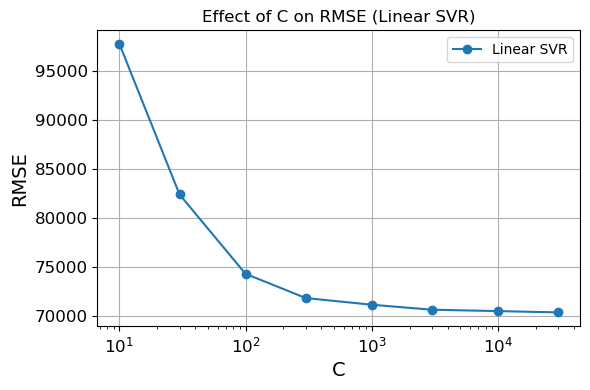

In [129]:


# Build pipeline with linear kernel
linear_svr = make_svr_pipeline(kernel='linear')

# Cross-validated baseline scores
linear_scores = cross_val_score(
    linear_svr, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=10
)
print(pd.Series(np.sqrt(-linear_scores)).describe())

# Grid search over C for linear kernel
linear_param_grid = {
    'svr__C': [10., 30., 100., 300., 1000., 3000., 10000., 30000.0]
}

grid_search = GridSearchCV(
    linear_svr,
    linear_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)
grid_search.fit(housing_prepared, housing_labels)

linear_best_rmse = np.sqrt(-grid_search.best_score_)
print("\nLinear SVR (best params):", grid_search.best_params_)
print("Best RMSE:", linear_best_rmse)

# Put grid search results into DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)
results_df['RMSE'] = np.sqrt(-results_df['mean_test_score'])

# Select the needed columns
print(results_df[['param_svr__C', 'mean_test_score', 'RMSE']])

# Plot RMSE vs C (log-scale)
plt.figure(figsize=(6, 4))
plt.plot(results_df['param_svr__C'], results_df['RMSE'],
         marker='o', label='Linear SVR')
plt.xscale('log')  # C varies exponentially
plt.xlabel('C')
plt.ylabel('RMSE')
plt.title('Effect of C on RMSE (Linear SVR)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




RBF SVR (best params): {'svr__C': 300000, 'svr__gamma': 0.1}
RMSE mean: 57127.15140002331
   param_svr__C  param_svr__gamma  mean_test_score           RMSE
0          5000              0.01    -5.300245e+09   72802.781056
1          5000              0.10    -5.038415e+09   70981.790954
2          5000              1.00    -9.813599e+09   99063.611476
3           100              0.01    -1.278427e+10  113067.561424
4           100              0.10    -1.208844e+10  109947.429481
5           100              1.00    -1.347871e+10  116097.859496
6        300000              0.01    -3.802831e+09   61667.100791
7        300000              0.10    -3.263511e+09   57127.151400
8        300000              1.00    -4.993046e+09   70661.486282


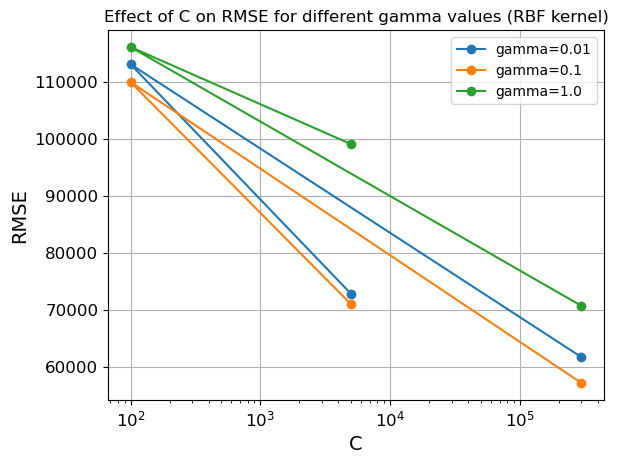

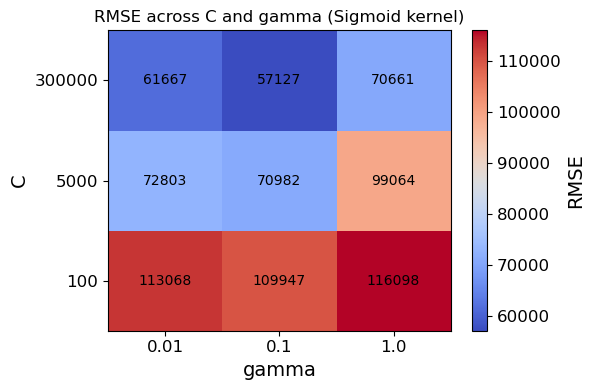

In [ ]:
# === Non-linear kernels with grid search ===
# RBF kernel
param_grid_rbf = {
    'svr__C': [5000, 100, 300000],
    'svr__gamma': [0.01, 0.1, 1]
}
rbf_svr = make_svr_pipeline(kernel='rbf')
grid_rbf = GridSearchCV(rbf_svr, param_grid_rbf,
                        scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_rbf.fit(housing_prepared, housing_labels)
rbf_best_rmse = np.sqrt(-grid_rbf.best_score_)
print("\nRBF SVR (best params):", grid_rbf.best_params_)
print("RMSE mean:", rbf_best_rmse)

rbf_scores = cross_val_score(
    rbf_svr, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=10
)
pd.Series(np.sqrt(-rbf_scores)).describe()

# Convert grid search results to a DataFrame
results_df = pd.DataFrame(grid_rbf.cv_results_)

# Add RMSE column
results_df['RMSE'] = np.sqrt(-results_df['mean_test_score'])

# Select the needed columns
print(results_df[['param_svr__C', 'param_svr__gamma', 'mean_test_score', 'RMSE']])

import matplotlib.pyplot as plt

for gamma_value in results_df['param_svr__gamma'].unique():
    subset = results_df[results_df['param_svr__gamma'] == gamma_value]
    plt.plot(subset['param_svr__C'], subset['RMSE'], marker='o', label=f'gamma={gamma_value}')

plt.xscale('log')  # C varies exponentially
plt.xlabel('C')
plt.ylabel('RMSE')
plt.title('Effect of C on RMSE for different gamma values (RBF kernel)')
plt.legend()
plt.grid(True)
plt.show()

# Put your grid search results into a DataFrame
results_df = pd.DataFrame(grid_rbf.cv_results_)

# Compute RMSE
results_df['RMSE'] = np.sqrt(-results_df['mean_test_score'])

pivot = results_df.pivot(index='param_svr__C',
                         columns='param_svr__gamma',
                         values='RMSE')
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

# Show the heatmap
cax = ax.imshow(pivot.values, cmap='coolwarm', aspect='auto', origin='lower')

# Set the ticks to the actual C and gamma values
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)

# Add labels
ax.set_xlabel('gamma')
ax.set_ylabel('C')
ax.set_title('RMSE across C and gamma (RBF kernel)')

# Add colour bar
fig.colorbar(cax, ax=ax, label='RMSE')

# Optional: annotate values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.0f}",
                ha='center', va='center', color='black')

plt.tight_layout()
plt.show()



In [114]:
#Poly kernel
param_grid_poly = {
    'svr__C': [10, 100, 1000],
    'svr__degree': [2],
    'svr__gamma': ['scale', 0.1, 1]
}
poly_svr = make_svr_pipeline(kernel='poly')
grid_poly = GridSearchCV(poly_svr, param_grid_poly,
                         scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_poly.fit(housing_prepared, housing_labels)
poly_best_rmse = np.sqrt(-grid_poly.best_score_)
print("\nPOLY SVR (best params):", grid_poly.best_params_)
print("RMSE mean:", poly_best_rmse)

polly_scores = cross_val_score(
    poly_svr, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=10
)
pd.Series(np.sqrt(-polly_scores)).describe()



POLY SVR (best params): {'svr__C': 10, 'svr__degree': 2, 'svr__gamma': 1}
RMSE mean: 94483.47492843165


count        10.000000
mean     116690.933642
std        4843.146440
min      110063.120678
25%      112859.928566
50%      116195.196984
75%      120518.708633
max      123082.711528
dtype: float64


SIGMOID SVR (best params): {'svr__C': 10000, 'svr__gamma': 0.01}
RMSE mean: 79812.06966344293
   param_svr__C  param_svr__gamma  mean_test_score          RMSE
0            10              0.01    -1.360867e+10  1.166562e+05
1            10              0.10    -1.316891e+10  1.147559e+05
2            10              1.00    -1.267867e+10  1.125996e+05
3           100              0.01    -1.307320e+10  1.143381e+05
4           100              0.10    -1.007446e+10  1.003716e+05
5           100              1.00    -8.742156e+09  9.349950e+04
6         10000              0.01    -6.369966e+09  7.981207e+04
7         10000              0.10    -3.813980e+11  6.175742e+05
8         10000              1.00    -8.324243e+12  2.885176e+06


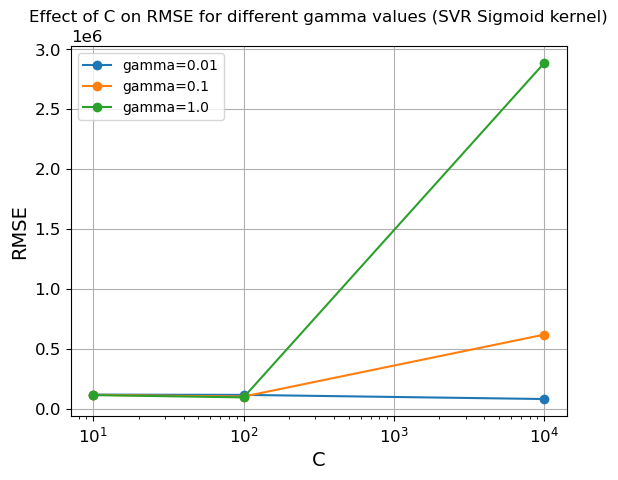

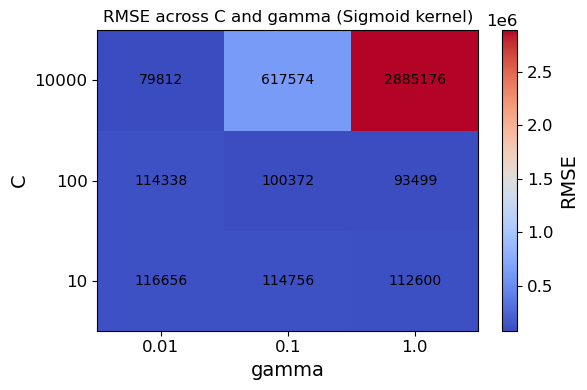

In [126]:
#Sigmoid kernel

param_grid_sigmoid = {
    'svr__C': [10, 100, 10000],
    'svr__gamma': [0.01, 0.1, 1]
}
sigmoid_svr = make_svr_pipeline(kernel='sigmoid')
grid_sigmoid = GridSearchCV(sigmoid_svr, param_grid_sigmoid,
                            scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
grid_sigmoid.fit(housing_prepared, housing_labels)
sigmoid_best_rmse = np.sqrt(-grid_sigmoid.best_score_)
print("\nSIGMOID SVR (best params):", grid_sigmoid.best_params_)
print("RMSE mean:", sigmoid_best_rmse)

sig_scores = cross_val_score(
    sigmoid_svr, housing_prepared, housing_labels,
    scoring="neg_mean_squared_error", cv=10
)
pd.Series(np.sqrt(-sig_scores)).describe()
pd.Series(grid_sigmoid).describe()


# Convert grid search results to a DataFrame
results_df = pd.DataFrame(grid_sigmoid.cv_results_)

# Add RMSE column
results_df['RMSE'] = np.sqrt(-results_df['mean_test_score'])

# Select the needed columns
print(results_df[['param_svr__C', 'param_svr__gamma', 'mean_test_score', 'RMSE']])

import matplotlib.pyplot as plt

for gamma_value in results_df['param_svr__gamma'].unique():
    subset = results_df[results_df['param_svr__gamma'] == gamma_value]
    plt.plot(subset['param_svr__C'], subset['RMSE'], marker='o', label=f'gamma={gamma_value}')

plt.xscale('log')  # C varies exponentially
plt.xlabel('C')
plt.ylabel('RMSE')
plt.title('Effect of C on RMSE for different gamma values (SVR Sigmoid kernel)')
plt.legend()
plt.grid(True)
plt.show()

# Put your grid search results into a DataFrame
results_df = pd.DataFrame(grid_sigmoid.cv_results_)

# Compute RMSE
results_df['RMSE'] = np.sqrt(-results_df['mean_test_score'])

pivot = results_df.pivot(index='param_svr__C',
                         columns='param_svr__gamma',
                         values='RMSE')
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))

# Show the heatmap
cax = ax.imshow(pivot.values, cmap='coolwarm', aspect='auto', origin='lower')

# Set the ticks to the actual C and gamma values
ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_xticklabels(pivot.columns)
ax.set_yticklabels(pivot.index)

# Add labels
ax.set_xlabel('gamma')
ax.set_ylabel('C')
ax.set_title('RMSE across C and gamma (Sigmoid kernel)')

# Add colour bar
fig.colorbar(cax, ax=ax, label='RMSE')

# Optional: annotate values
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.0f}",
                ha='center', va='center', color='black')

plt.tight_layout()
plt.show()




# Fine-Tune Your Model

## Grid Search

In [116]:
from sklearn.model_selection import GridSearchCV

linera_param_grid = [
    # try 12 (3×4) combinations of hyperparameters
    {'n_estimators': [1, 5, 20], 'max_features': [1, 3, 5, 7]},
    # then try 6 (2×3) combinations with bootstrap set as False
    {'bootstrap': [False], 'n_estimators': [3, 10], 'max_features': [2, 3, 4]},
  ]

forest_reg = RandomForestRegressor(random_state=42)
# train across 5 folds, that's a total of (12+6)*5=90 rounds of training 
grid_search = GridSearchCV(forest_reg, linera_param_grid, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)
grid_search.fit(housing_prepared, housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid=[{'max_features': [1, 3, 5, 7],
                          'n_estimators': [1, 5, 20]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             return_train_score=True, scoring='neg_mean_squared_error')

The best hyperparameter combination found:

In [117]:
grid_search.best_params_

{'max_features': 5, 'n_estimators': 20}

In [118]:
grid_search.best_estimator_

RandomForestRegressor(max_features=5, n_estimators=20, random_state=42)

Let's look at the score of each hyperparameter combination tested during the grid search:

In [119]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

99816.18658973963 {'max_features': 1, 'n_estimators': 1}
66762.37490042373 {'max_features': 1, 'n_estimators': 5}
60377.8185495584 {'max_features': 1, 'n_estimators': 20}
88819.06103535766 {'max_features': 3, 'n_estimators': 1}
61501.26216321569 {'max_features': 3, 'n_estimators': 5}
56904.41448967789 {'max_features': 3, 'n_estimators': 20}
82258.99619158123 {'max_features': 5, 'n_estimators': 1}
59664.74976047203 {'max_features': 5, 'n_estimators': 5}
54477.322175116715 {'max_features': 5, 'n_estimators': 20}
80955.35279290189 {'max_features': 7, 'n_estimators': 1}
59564.74656564213 {'max_features': 7, 'n_estimators': 5}
54600.65711476496 {'max_features': 7, 'n_estimators': 20}
68501.33397457977 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
59522.13943108108 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
65534.8871431465 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
57550.99494688273 {'bootstrap': False, 'max_features': 3, 'n_estimators': 10}
629

In [120]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_n_estimators,param_bootstrap,params,split0_test_score,split1_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.009466,0.001092,0.001637,0.000130,1,1,NaN,"{'max_features': 1, 'n_estimators': 1}",-8.965974e+09,-9.540709e+09,...,-9.963271e+09,6.722805e+08,18,-3.569460e+09,-3.999281e+09,-4.128123e+09,-3.053442e+09,-3.518852e+09,-3.653832e+09,3.821240e+08
1,0.033751,0.000472,0.002771,0.000249,1,5,NaN,"{'max_features': 1, 'n_estimators': 5}",-4.297890e+09,-4.653231e+09,...,-4.457215e+09,1.718307e+08,13,-9.762846e+08,-1.100112e+09,-9.764598e+08,-9.883500e+08,-9.550732e+08,-9.992560e+08,5.155655e+07
2,0.121546,0.004166,0.006618,0.000568,1,20,NaN,"{'max_features': 1, 'n_estimators': 20}",-3.539069e+09,-3.662640e+09,...,-3.645481e+09,1.690727e+08,9,-5.890510e+08,-6.311964e+08,-5.691430e+08,-5.974680e+08,-5.845443e+08,-5.942805e+08,2.062514e+07
3,0.011000,0.000400,0.001340,0.000072,3,1,NaN,"{'max_features': 3, 'n_estimators': 1}",-7.959022e+09,-7.363392e+09,...,-7.888826e+09,4.989717e+08,17,-3.029078e+09,-2.822653e+09,-2.857580e+09,-2.705031e+09,-2.991772e+09,-2.881223e+09,1.175714e+08
4,0.050820,0.001893,0.002419,0.000056,3,5,NaN,"{'max_features': 3, 'n_estimators': 5}",-3.726417e+09,-3.750245e+09,...,-3.782405e+09,1.782561e+08,10,-8.351166e+08,-8.803722e+08,-8.271396e+08,-8.412453e+08,-8.129207e+08,-8.393589e+08,2.259176e+07
5,0.188700,0.001761,0.006071,0.000215,3,20,NaN,"{'max_features': 3, 'n_estimators': 20}",-3.331843e+09,-3.129242e+09,...,-3.238112e+09,1.692068e+08,4,-5.106068e+08,-5.079479e+08,-4.880449e+08,-4.850994e+08,-4.799627e+08,-4.943323e+08,1.250206e+07
6,0.014547,0.000530,0.001414,0.000049,5,1,NaN,"{'max_features': 5, 'n_estimators': 1}",-7.062345e+09,-6.979097e+09,...,-6.766542e+09,2.624010e+08,16,-2.457138e+09,-2.581131e+09,-2.797647e+09,-2.282379e+09,-2.272679e+09,-2.478195e+09,1.968093e+08
7,0.069775,0.001504,0.002505,0.000195,5,5,NaN,"{'max_features': 5, 'n_estimators': 5}",-3.408205e+09,-3.568582e+09,...,-3.559882e+09,1.279262e+08,8,-7.392151e+08,-7.704821e+08,-7.894115e+08,-7.845895e+08,-7.492915e+08,-7.665979e+08,1.953755e+07
8,0.304713,0.011014,0.006709,0.000828,5,20,NaN,"{'max_features': 5, 'n_estimators': 20}",-3.023294e+09,-2.879848e+09,...,-2.967779e+09,1.597608e+08,1,-4.642655e+08,-4.701923e+08,-4.758158e+08,-4.620007e+08,-4.578568e+08,-4.660262e+08,6.312477e+06
9,0.021189,0.001130,0.001633,0.000077,7,1,NaN,"{'max_features': 7, 'n_estimators': 1}",-7.043493e+09,-6.914886e+09,...,-6.553769e+09,3.953672e+08,15,-2.079344e+09,-2.227235e+09,-2.209949e+09,-2.200316e+09,-2.338950e+09,-2.211159e+09,8.256317e+07


## Randomized Search

In [121]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_features': randint(low=1, high=8),
    }

forest_reg = RandomForestRegressor(random_state=42)
rnd_search = RandomizedSearchCV(forest_reg, param_distributions=param_distribs,
                                n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

KeyboardInterrupt: 

In [ ]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

52817.015590656985 {'max_features': 7, 'n_estimators': 180}
54886.39692731077 {'max_features': 5, 'n_estimators': 15}
54549.20443859006 {'max_features': 3, 'n_estimators': 72}
54418.91173282526 {'max_features': 5, 'n_estimators': 21}
53095.172240396874 {'max_features': 7, 'n_estimators': 122}
54487.02668341943 {'max_features': 3, 'n_estimators': 75}
54283.49279368737 {'max_features': 3, 'n_estimators': 88}
53370.00021924188 {'max_features': 5, 'n_estimators': 100}
54015.17462348843 {'max_features': 3, 'n_estimators': 150}
69873.27319965512 {'max_features': 5, 'n_estimators': 2}


## Analyze the Best Models and Their Errors

In [ ]:
feature_importances = grid_search.best_estimator_.feature_importances_
feature_importances

array([0.06069799, 0.0579997 , 0.0401847 , 0.02358896, 0.02035724,
       0.02066073, 0.02005618, 0.33013986, 0.05779835, 0.1021262 ,
       0.08783668, 0.01655044, 0.14251321, 0.00133427, 0.00692855,
       0.01122694])

In [ ]:
extra_attribs = ["rooms_per_hhold", "pop_per_hhold", "bedrooms_per_room"]
#cat_encoder = cat_pipeline.named_steps["cat_encoder"] # old solution
cat_encoder = full_pipeline.named_transformers_["cat"]
cat_one_hot_attribs = list(cat_encoder.categories_[0])
attributes = num_attribs + extra_attribs + cat_one_hot_attribs
sorted(zip(feature_importances, attributes), reverse=True)

[(np.float64(0.3301398626642117), 'median_income'),
 (np.float64(0.14251320858767833), 'INLAND'),
 (np.float64(0.10212620363131286), 'pop_per_hhold'),
 (np.float64(0.08783668183598711), 'bedrooms_per_room'),
 (np.float64(0.06069799320686352), 'longitude'),
 (np.float64(0.057999696997895686), 'latitude'),
 (np.float64(0.057798350253996045), 'rooms_per_hhold'),
 (np.float64(0.040184701058643864), 'housing_median_age'),
 (np.float64(0.023588957551929017), 'total_rooms'),
 (np.float64(0.02066073332469068), 'population'),
 (np.float64(0.0203572376386905), 'total_bedrooms'),
 (np.float64(0.020056182679854415), 'households'),
 (np.float64(0.016550437107548017), '<1H OCEAN'),
 (np.float64(0.011226938809535611), 'NEAR OCEAN'),
 (np.float64(0.006928548984013317), 'NEAR BAY'),
 (np.float64(0.0013342656671492853), 'ISLAND')]

## Evaluate Your System on the Test Set

In [ ]:
final_model = grid_search.best_estimator_

X_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

X_test_prepared = full_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)

final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)

In [ ]:
final_rmse

np.float64(21232.991730859438)

We can compute a 95% confidence interval for the test RMSE:

In [ ]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
np.sqrt(stats.t.interval(confidence, len(squared_errors) - 1,
                         loc=squared_errors.mean(),
                         scale=stats.sem(squared_errors)))

array([20363.38903977, 22068.35432244])

We could compute the interval manually like this:

In [ ]:
m = len(squared_errors)
mean = squared_errors.mean()
tscore = stats.t.ppf((1 + confidence) / 2, df=m - 1)
tmargin = tscore * squared_errors.std(ddof=1) / np.sqrt(m)
np.sqrt(mean - tmargin), np.sqrt(mean + tmargin)

(np.float64(20363.389039767626), np.float64(22068.354322435607))

Alternatively, we could use a z-scores rather than t-scores:

In [ ]:
zscore = stats.norm.ppf((1 + confidence) / 2)
zmargin = zscore * squared_errors.std(ddof=1) / np.sqrt(m)
np.sqrt(mean - zmargin), np.sqrt(mean + zmargin)

(np.float64(20363.64951905581), np.float64(22068.11396450881))

# Extra material

## A full pipeline with both preparation and prediction

In [ ]:
full_pipeline_with_predictor = Pipeline([
        ("preparation", full_pipeline),
        ("linear", LinearRegression())
    ])

full_pipeline_with_predictor.fit(housing, housing_labels)
full_pipeline_with_predictor.predict(some_data)

array([421732.95505945])

## Model persistence using joblib

In [ ]:
my_model = full_pipeline_with_predictor

In [ ]:
import joblib
joblib.dump(my_model, "my_model.pkl") # DIFF
#...
my_model_loaded = joblib.load("my_model.pkl") # DIFF

## Example SciPy distributions for `RandomizedSearchCV`

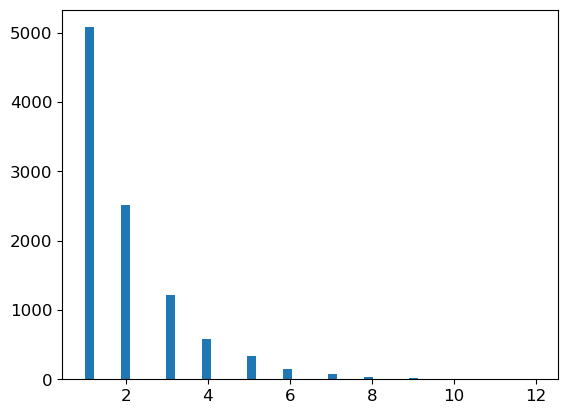

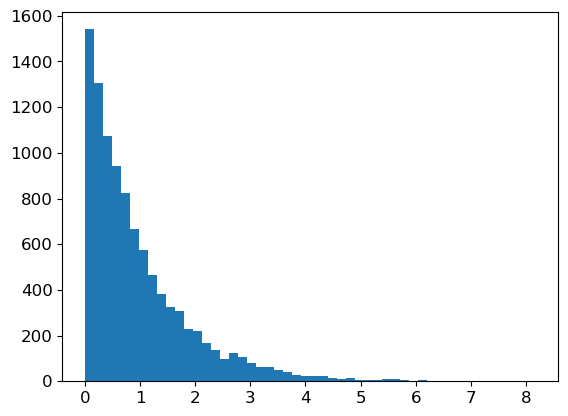

In [ ]:
from scipy.stats import geom, expon
geom_distrib=geom(0.5).rvs(10000, random_state=42)
expon_distrib=expon(scale=1).rvs(10000, random_state=42)
plt.hist(geom_distrib, bins=50)
plt.show()
plt.hist(expon_distrib, bins=50)
plt.show()

# Exercise solutions

## 1.

Question: Try a Support Vector Machine regressor (`sklearn.svm.SVR`), with various hyperparameters such as `kernel="linear"` (with various values for the `C` hyperparameter) or `kernel="rbf"` (with various values for the `C` and `gamma` hyperparameters). Don't worry about what these hyperparameters mean for now. How does the best `SVR` predictor perform?

**Warning**: the following cell may take close to 30 minutes to run, or more depending on your hardware.

In [ ]:
from sklearn.model_selection import GridSearchCV

linera_param_grid = [
        {'kernel': ['linear'], 'C': [10., 30., 100., 300., 1000., 3000., 10000., 30000.0]},
        {'kernel': ['rbf'], 'C': [1.0, 3.0, 10., 30., 100., 300., 1000.0],
         'gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0]},
    ]

svm_reg = SVR()
grid_search = GridSearchCV(svm_reg, linera_param_grid, cv=5, scoring='neg_mean_squared_error', verbose=2)
grid_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END ..............................C=10.0, kernel=linear; total time=   0.9s
[CV] END ..............................C=10.0, kernel=linear; total time=   1.0s
[CV] END ..............................C=10.0, kernel=linear; total time=   1.1s
[CV] END ..............................C=10.0, kernel=linear; total time=   0.8s
[CV] END ..............................C=10.0, kernel=linear; total time=   1.0s
[CV] END ..............................C=30.0, kernel=linear; total time=   1.1s
[CV] END ..............................C=30.0, kernel=linear; total time=   1.1s
[CV] END ..............................C=30.0, kernel=linear; total time=   1.1s
[CV] END ..............................C=30.0, kernel=linear; total time=   1.2s
[CV] END ..............................C=30.0, kernel=linear; total time=   1.2s
[CV] END .............................C=100.0, kernel=linear; total time=   1.1s
[CV] END .............................C=100.0, 

GridSearchCV(cv=5, estimator=SVR(),
             param_grid=[{'C': [10.0, 30.0, 100.0, 300.0, 1000.0, 3000.0,
                                10000.0, 30000.0],
                          'kernel': ['linear']},
                         {'C': [1.0, 3.0, 10.0, 30.0, 100.0, 300.0, 1000.0],
                          'gamma': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
                          'kernel': ['rbf']}],
             scoring='neg_mean_squared_error', verbose=2)

The best model achieves the following score (evaluated using 5-fold cross validation):

In [ ]:
negative_mse = grid_search.best_score_
rmse = np.sqrt(-negative_mse)
rmse

np.float64(70249.49818396156)

That's much worse than the `RandomForestRegressor`. Let's check the best hyperparameters found:

In [ ]:
grid_search.best_params_

{'C': 30000.0, 'kernel': 'linear'}

The linear kernel seems better than the RBF kernel. Notice that the value of `C` is the maximum tested value. When this happens you definitely want to launch the grid search again with higher values for `C` (removing the smallest values), because it is likely that higher values of `C` will be better.

## 2.

Question: Try replacing `GridSearchCV` with `RandomizedSearchCV`.

**Warning**: the following cell may take close to 45 minutes to run, or more depending on your hardware.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import expon, reciprocal

# see https://docs.scipy.org/doc/scipy/reference/stats.html
# for `expon()` and `reciprocal()` documentation and more probability distribution functions.

# Note: gamma is ignored when kernel is "linear"
param_distribs = {
        'kernel': ['linear', 'rbf'],
        'C': reciprocal(20, 200000),
        'gamma': expon(scale=1.0),
    }

svm_reg = SVR()
rnd_search = RandomizedSearchCV(svm_reg, param_distributions=param_distribs,
                                n_iter=50, cv=5, scoring='neg_mean_squared_error',
                                verbose=2, random_state=42)
rnd_search.fit(housing_prepared, housing_labels)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END C=629.7823295913721, gamma=3.010121430917521, kernel=linear; total time=   1.3s
[CV] END C=629.7823295913721, gamma=3.010121430917521, kernel=linear; total time=   0.6s
[CV] END C=629.7823295913721, gamma=3.010121430917521, kernel=linear; total time=   0.8s
[CV] END C=629.7823295913721, gamma=3.010121430917521, kernel=linear; total time=   1.0s
[CV] END C=629.7823295913721, gamma=3.010121430917521, kernel=linear; total time=   1.2s
[CV] END C=26290.20646430022, gamma=0.9084469696321253, kernel=rbf; total time=   1.5s
[CV] END C=26290.20646430022, gamma=0.9084469696321253, kernel=rbf; total time=   1.1s
[CV] END C=26290.20646430022, gamma=0.9084469696321253, kernel=rbf; total time=   1.6s
[CV] END C=26290.20646430022, gamma=0.9084469696321253, kernel=rbf; total time=   0.8s
[CV] END C=26290.20646430022, gamma=0.9084469696321253, kernel=rbf; total time=   0.9s
[CV] END C=84.14107900575871, gamma=0.059838768608680676, 

RandomizedSearchCV(cv=5, estimator=SVR(), n_iter=50,
                   param_distributions={'C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000022AE6B52710>,
                                        'gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000022AE6B534D0>,
                                        'kernel': ['linear', 'rbf']},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

The best model achieves the following score (evaluated using 5-fold cross validation):

In [ ]:
negative_mse = rnd_search.best_score_
rmse = np.sqrt(-negative_mse)
rmse

np.float64(58016.02918586411)

Now this is much closer to the performance of the `RandomForestRegressor` (but not quite there yet). Let's check the best hyperparameters found:

In [ ]:
rnd_search.best_params_

{'C': np.float64(157055.10989448498),
 'gamma': np.float64(0.26497040005002437),
 'kernel': 'rbf'}

This time the search found a good set of hyperparameters for the RBF kernel. Randomized search tends to find better hyperparameters than grid search in the same amount of time.

Let's look at the exponential distribution we used, with `scale=1.0`. Note that some samples are much larger or smaller than 1.0, but when you look at the log of the distribution, you can see that most values are actually concentrated roughly in the range of exp(-2) to exp(+2), which is about 0.1 to 7.4.

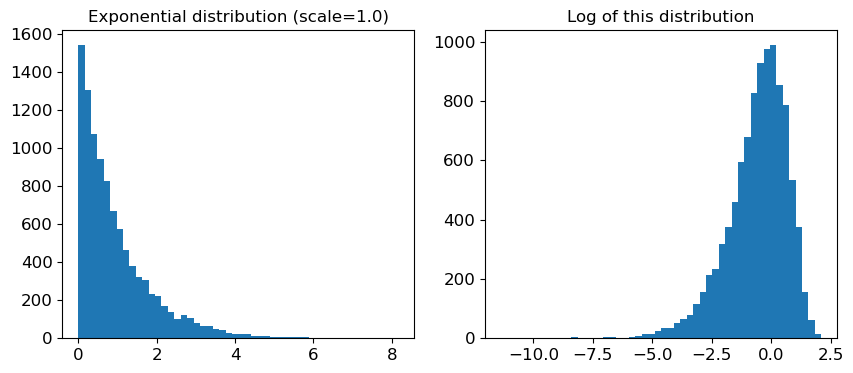

In [ ]:
expon_distrib = expon(scale=1.)
samples = expon_distrib.rvs(10000, random_state=42)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title("Exponential distribution (scale=1.0)")
plt.hist(samples, bins=50)
plt.subplot(122)
plt.title("Log of this distribution")
plt.hist(np.log(samples), bins=50)
plt.show()

The distribution we used for `C` looks quite different: the scale of the samples is picked from a uniform distribution within a given range, which is why the right graph, which represents the log of the samples, looks roughly constant. This distribution is useful when you don't have a clue of what the target scale is:

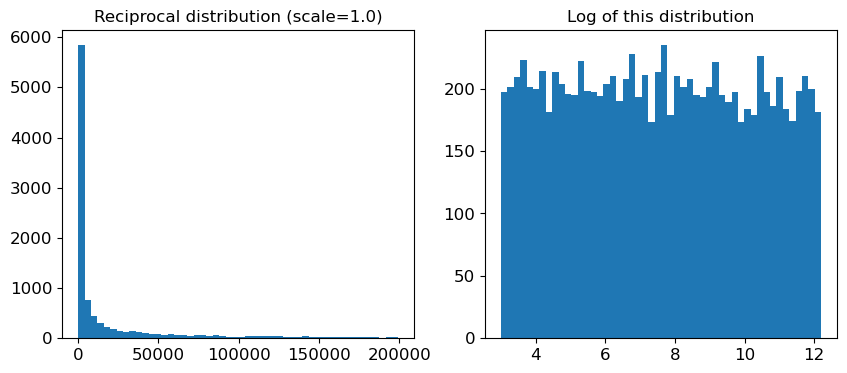

In [ ]:
reciprocal_distrib = reciprocal(20, 200000)
samples = reciprocal_distrib.rvs(10000, random_state=42)
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.title("Reciprocal distribution (scale=1.0)")
plt.hist(samples, bins=50)
plt.subplot(122)
plt.title("Log of this distribution")
plt.hist(np.log(samples), bins=50)
plt.show()

The reciprocal distribution is useful when you have no idea what the scale of the hyperparameter should be (indeed, as you can see on the figure on the right, all scales are equally likely, within the given range), whereas the exponential distribution is best when you know (more or less) what the scale of the hyperparameter should be.

## 3.

Question: Try adding a transformer in the preparation pipeline to select only the most important attributes.

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

def indices_of_top_k(arr, k):
    return np.sort(np.argpartition(np.array(arr), -k)[-k:])

class TopFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(self, feature_importances, k):
        self.feature_importances = feature_importances
        self.k = k
    def fit(self, X, y=None):
        self.feature_indices_ = indices_of_top_k(self.feature_importances, self.k)
        return self
    def transform(self, X):
        return X[:, self.feature_indices_]

Note: this feature selector assumes that you have already computed the feature importances somehow (for example using a `RandomForestRegressor`). You may be tempted to compute them directly in the `TopFeatureSelector`'s `fit()` method, however this would likely slow down grid/randomized search since the feature importances would have to be computed for every hyperparameter combination (unless you implement some sort of cache).

Let's define the number of top features we want to keep:

In [ ]:
k = 5

Now let's look for the indices of the top k features:

In [ ]:
top_k_feature_indices = indices_of_top_k(feature_importances, k)
top_k_feature_indices

array([ 0,  7,  9, 10, 12])

In [ ]:
np.array(attributes)[top_k_feature_indices]

array(['longitude', 'median_income', 'pop_per_hhold', 'bedrooms_per_room',
       'INLAND'], dtype='<U18')

Let's double check that these are indeed the top k features:

In [ ]:
sorted(zip(feature_importances, attributes), reverse=True)[:k]

[(np.float64(0.3301398626642117), 'median_income'),
 (np.float64(0.14251320858767833), 'INLAND'),
 (np.float64(0.10212620363131286), 'pop_per_hhold'),
 (np.float64(0.08783668183598711), 'bedrooms_per_room'),
 (np.float64(0.06069799320686352), 'longitude')]

Looking good... Now let's create a new pipeline that runs the previously defined preparation pipeline, and adds top k feature selection:

In [ ]:
preparation_and_feature_selection_pipeline = Pipeline([
    ('preparation', full_pipeline),
    ('feature_selection', TopFeatureSelector(feature_importances, k))
])

In [ ]:
housing_prepared_top_k_features = preparation_and_feature_selection_pipeline.fit_transform(housing)

Let's look at the features of the first 3 instances:

In [ ]:
housing_prepared_top_k_features[0:3]

array([[ 0.57507019,  2.35845461, -0.43699104, -0.88424924,  0.        ],
       [-0.43480141,  0.61735909,  0.03395612, -0.96141918,  0.        ],
       [ 0.54522177,  0.28422164, -0.01843971, -0.43826533,  0.        ]])

Now let's double check that these are indeed the top k features:

In [ ]:
housing_prepared[0:3, top_k_feature_indices]

array([[ 0.57507019,  2.35845461, -0.43699104, -0.88424924,  0.        ],
       [-0.43480141,  0.61735909,  0.03395612, -0.96141918,  0.        ],
       [ 0.54522177,  0.28422164, -0.01843971, -0.43826533,  0.        ]])

Works great!  :)

## 4.

Question: Try creating a single pipeline that does the full data preparation plus the final prediction.

In [ ]:
prepare_select_and_predict_pipeline = Pipeline([
    ('preparation', full_pipeline),
    ('feature_selection', TopFeatureSelector(feature_importances, k)),
    ('svm_reg', SVR(**rnd_search.best_params_))
])

In [ ]:
prepare_select_and_predict_pipeline.fit(housing, housing_labels)

Pipeline(steps=[('preparation',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('attribs_adder',
                                                                   CombinedAttributesAdder()),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat', OneHotEncoder(),
                                                  ['ocean_proximity'])])),
                ('feature_selection',
                 TopFeatureSelector(feature_importances=array([0.06069799, 0.0579997 , 0.0401847 , 0.02358896, 0.02035724,
       0.02066073, 0.02005618, 0.33013986, 0.05779835, 0.1021262 ,
       0.08783668, 0.01655044, 0.14251321, 0.00133427, 0.00692855,
       0.01122694]),
                                    k=5)),
                ('svm_reg',
                 SVR(C=np.float64(157055.10989448498),
                     gamma=np.float64(0.26497040005002437)))])

Let's try the full pipeline on a few instances:

In [ ]:
some_data = housing.iloc[:4]
some_labels = housing_labels.iloc[:4]

print("Predictions:\t", prepare_select_and_predict_pipeline.predict(some_data))
print("Labels:\t\t", list(some_labels))

Predictions:	 [499738.11790021 229986.04057477 221675.33117598 165743.48852954]
Labels:		 [500001.0, 162500.0, 204600.0, 159700.0]


Well, the full pipeline seems to work fine. Of course, the predictions are not fantastic: they would be better if we used the best `RandomForestRegressor` that we found earlier, rather than the best `SVR`.

## 5.

Question: Automatically explore some preparation options using `GridSearchCV`.

**Warning**: the following cell may take close to 45 minutes to run, or more depending on your hardware.

**Note:** In the code below, I've set the `OneHotEncoder`'s `handle_unknown` hyperparameter to `'ignore'`, to avoid warnings during training. Without this, the `OneHotEncoder` would default to `handle_unknown='error'`, meaning that it would raise an error when transforming any data containing a category it didn't see during training. If we kept the default, then the `GridSearchCV` would run into errors during training when evaluating the folds in which not all the categories are in the training set. This is likely to happen since there's only one sample in the `'ISLAND'` category, and it may end up in the test set in some of the folds. So some folds would just be dropped by the `GridSearchCV`, and it's best to avoid that.

In [ ]:
full_pipeline.named_transformers_["cat"].handle_unknown = 'ignore'

linera_param_grid = [{
    'preparation__num__imputer__strategy': ['mean', 'median', 'most_frequent'],
    'feature_selection__k': list(range(1, len(feature_importances) + 1))
}]

grid_search_prep = GridSearchCV(prepare_select_and_predict_pipeline, linera_param_grid, cv=5,
                                scoring='neg_mean_squared_error', verbose=2)
grid_search_prep.fit(housing, housing_labels)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=mean; total time=   2.1s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=mean; total time=   1.8s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=mean; total time=   1.9s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=mean; total time=   2.0s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=mean; total time=   1.9s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=median; total time=   1.9s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=median; total time=   1.9s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=median; total time=   2.0s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=median; total time=   1.9s
[CV] END feature_selection__k=1, preparation__num__imputer__strategy=median; total t

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preparation',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('attribs_adder',
                                                                                          CombinedAttributesAdder()),
                                                                                         ('std_scaler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_inc...
       0.08783668, 0.01655044, 0.14251321, 0.00133427, 0.00692855,
       0.01122694]),
                                                           k=5)),
                                       ('svm_reg',
                                        SVR(C=np.float64(157055.10989448498),
                                            gamma=np.float64(0.26497040005002437)))]),
             param_grid=[{'feature_selection__k': [1, 2, 3, 4, 5, 6, 7, 8, 9,
                                                   10, 11, 12, 13, 14, 15, 16],
                          'preparation__num__imputer__strategy': ['mean',
                                                                  'median',
                                                                  'most_frequent']}],
             scoring='neg_mean_squared_error', verbose=2)

In [ ]:
grid_search_prep.best_params_

{'feature_selection__k': 8,
 'preparation__num__imputer__strategy': 'most_frequent'}

The best imputer strategy is `most_frequent` and apparently almost all features are useful (15 out of 16). The last one (`ISLAND`) seems to just add some noise.

Congratulations! You already know quite a lot about Machine Learning. :)